# Extension: non-IID data, every attack type, and unseen devices

This notebook extends the federated anomaly detection project (see notebooks 01 to 03 and the README)). It is self-contained: it only needs the raw N-BaIoT files, not the output of the other notebook.

**Three questions**

1. **Non-IID.** The 4 devices have very different traffic and very different amounts of it. Does plain FedAvg suffer from that? Do FedProx, equal client weighting, or local scaling help?
2. **Attack coverage.** The first evaluation only used 4 of the 10 attack files per device. Does the model still do well on all 10?
3. **Unseen devices.** If a new device joins after training, does the global model still work on it?

**On "unseen attacks".** All models train on benign traffic only, so every attack is unseen at training time. The real gap in the first evaluation was coverage: 6 of the 10 attack types were never used for testing. Question 2 closes that gap.

**On "non-IID".** Because training uses benign data only, labels cannot be skewed across clients the way they are in a normal classification task. The skew that exists here is between devices: different feature scales, different traffic patterns, and very different data sizes (roughly 13k benign rows for the thermostat vs roughly 175k for the baby monitor).

**What differs from the main notebook**

- Local training uses real minibatches (batch size 256). The main notebook ran 5 full-batch gradient steps per round.
- Every result is averaged over 3 seeds, because at AUC close to 0.9999 a difference in the 4th decimal place can easily be noise.
- Besides ROC-AUC, it reports benign recall (TNR) and attack recall (TPR) at a threshold taken from each device's own benign training data.
- The federated loop is plain PyTorch instead of Flower simulation. It is the same algorithm (FedAvg) but faster to repeat many times and easy to swap for FedProx. The first federated row should land close to the Flower result as a sanity check.

## Setup

In [4]:
import os, copy, time, json, subprocess
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_DIR = "/content/data"
SAVE_DIR = "/content/drive/MyDrive/nbaiot-project/processed"

try:
    from google.colab import drive
    if not os.path.exists("/content/drive/MyDrive"):
        drive.mount("/content/drive")
except ImportError:
    pass
os.makedirs(SAVE_DIR, exist_ok=True)

# ---- experiment settings ----
ROUNDS = 10               # federated rounds
SEEDS = [0, 1, 2]         # every experiment is repeated for each seed
BATCH = 256
LR = 1e-3
MAX_ATTACK_ROWS = 20000   # cap per attack file, keeps memory small. AUC is stable at this size
print("device:", DEVICE)

Mounted at /content/drive
device: cpu


## Get the raw data

Same Kaggle download as the main notebook (about 1.75 GB). It needs a `KAGGLE_TOKEN` secret in Colab, and it is skipped if `/content/data` already exists.

In [5]:
if not os.path.exists(f"{DATA_DIR}/device_info.csv"):
    from google.colab import userdata
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    token_path = os.path.expanduser("~/.kaggle/access_token")
    with open(token_path, "w") as f:
        f.write(userdata.get("KAGGLE_TOKEN"))
    os.chmod(token_path, 0o600)
    subprocess.run("pip install -q kaggle", shell=True, check=True)
    subprocess.run("kaggle datasets download -d mkashifn/nbaiot-dataset -p /content", shell=True, check=True)
    subprocess.run(f"unzip -q -o /content/nbaiot-dataset.zip -d {DATA_DIR}", shell=True, check=True)
    print("downloaded")
else:
    print("data already there")

downloaded


## Load every attack type

Benign data is split 70/30 in file order, exactly like the main notebook, so train and test sets match. This time **all** attack files are loaded (up to 10 per device). Each file is capped at 20,000 random rows to keep memory low.

`ORIGINAL_ATTACKS` are the 4 types used in the first evaluation. The other 6 are new.

In [6]:
DEVICE_IDS = [1, 2, 4, 8]
DEVICE_NAMES = {
    1: "Danmini_Doorbell",
    2: "Ecobee_Thermostat",
    4: "Philips_B120N10_Baby_Monitor",
    8: "SimpleHome_XCS7_1002_WHT_Security_Camera",
}
SHORT = {
    "Danmini_Doorbell": "Doorbell",
    "Ecobee_Thermostat": "Thermostat",
    "Philips_B120N10_Baby_Monitor": "BabyMonitor",
    "SimpleHome_XCS7_1002_WHT_Security_Camera": "Camera",
}
GAFGYT = ["combo", "junk", "scan", "tcp", "udp"]
MIRAI = ["ack", "scan", "syn", "udp", "udpplain"]
ORIGINAL_ATTACKS = {"gafgyt_combo", "gafgyt_junk", "mirai_ack", "mirai_scan"}


def load_all(seed=42):
    rng = np.random.default_rng(seed)
    out = {}
    for did in DEVICE_IDS:
        name = DEVICE_NAMES[did]
        benign = pd.read_csv(f"{DATA_DIR}/{did}.benign.csv").values.astype(np.float32)
        n_train = int(len(benign) * 0.7)
        c = {"train": benign[:n_train], "test_benign": benign[n_train:], "attacks": {}}
        for fam, kinds in [("gafgyt", GAFGYT), ("mirai", MIRAI)]:
            for a in kinds:
                path = f"{DATA_DIR}/{did}.{fam}.{a}.csv"
                if not os.path.exists(path):
                    continue
                arr = pd.read_csv(path).values.astype(np.float32)
                if len(arr) > MAX_ATTACK_ROWS:
                    arr = arr[rng.choice(len(arr), MAX_ATTACK_ROWS, replace=False)]
                c["attacks"][f"{fam}_{a}"] = arr
        out[name] = c
    return out


clients = load_all()
NAMES = list(clients)
D = clients[NAMES[0]]["train"].shape[1]

rows = []
for n in NAMES:
    c = clients[n]
    rows.append({"device": SHORT[n], "benign_train": len(c["train"]),
                 "benign_test": len(c["test_benign"]), "attack_types": len(c["attacks"]),
                 "attack_rows": sum(len(v) for v in c["attacks"].values())})
pd.DataFrame(rows)

,device,benign_train,benign_test,attack_types,attack_rows
0,Doorbell,34683,14865,10,200000
1,Thermostat,9179,3934,10,200000
2,BabyMonitor,122667,52573,10,200000
3,Camera,32609,13976,10,200000


## Scaling

Two ways to standardize the features:

- **Shared scaler.** One mean and std for all devices, as in the main notebook. This does not require pooling raw data. Each client sends only its row count, sum, and sum of squares, and the server combines them into the same mean and std. No raw rows leave a device.
- **Local scaler.** Each device uses its own mean and std and shares nothing. This removes the offset between devices, but it can blow up features that barely move on one device.

In [7]:
def make_scaler(X):
    X = X.astype(np.float64)
    mean = X.mean(0)
    std = X.std(0)
    std[std < 1e-8] = 1.0
    return mean, std


def federated_scaler(names):
    """Combine per-client (count, sum, sum of squares). No raw rows are shared."""
    n, s, ss = 0, 0.0, 0.0
    for nm in names:
        X = clients[nm]["train"].astype(np.float64)
        n += len(X)
        s = s + X.sum(0)
        ss = ss + (X ** 2).sum(0)
    mean = s / n
    std = np.sqrt(np.maximum(ss / n - mean ** 2, 0))
    std[std < 1e-8] = 1.0
    return mean, std


def apply(scaler, X):
    mean, std = scaler
    return ((X - mean) / std).astype(np.float32)


SHARED = federated_scaler(NAMES)
SHARED_BY_CLIENT = {n: SHARED for n in NAMES}
LOCAL_BY_CLIENT = {n: make_scaler(clients[n]["train"]) for n in NAMES}

# sanity check: the federated scaler should match a scaler fit on pooled data
pooled = make_scaler(np.vstack([clients[n]["train"] for n in NAMES]))
print("max mean diff:", np.abs(SHARED[0] - pooled[0]).max() / (np.abs(pooled[0]).max() + 1e-12), "(relative)")

max mean diff: 1.631167677380544e-16 (relative)


## Model, local training, aggregation

Same autoencoder as before (115 -> 64 -> 16 -> 64 -> 115). Local training has an optional FedProx term that adds `(mu/2) * ||w - w_global||^2` to the loss. It pulls each client back toward the global model and limits client drift.

In [8]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, 64), nn.ReLU(),
                                     nn.Linear(64, latent_dim), nn.ReLU())
        self.decoder = nn.Sequential(nn.Linear(latent_dim, 64), nn.ReLU(),
                                     nn.Linear(64, input_dim))
    def forward(self, x):
        return self.decoder(self.encoder(x))


def set_seed(s):
    np.random.seed(s)
    torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)


def to_tensor(X):
    return torch.from_numpy(X).to(DEVICE)


def local_train(model, X, epochs=1, mu=0.0, global_params=None):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    n = X.size(0)
    for _ in range(epochs):
        perm = torch.randperm(n, device=X.device)
        for i in range(0, n, BATCH):
            b = X[perm[i:i + BATCH]]
            opt.zero_grad()
            loss = ((model(b) - b) ** 2).mean()
            if mu > 0:
                prox = sum(((p - g) ** 2).sum() for p, g in zip(model.parameters(), global_params))
                loss = loss + (mu / 2) * prox
            loss.backward()
            opt.step()


def aggregate(states, weights):
    w = np.asarray(weights, dtype=np.float64)
    w = w / w.sum()
    return {k: sum(float(wi) * s[k].float() for wi, s in zip(w, states)) for k in states[0]}


@torch.no_grad()
def recon_error(model, X, chunk=65536):
    model.eval()
    out = []
    for i in range(0, len(X), chunk):
        xb = to_tensor(X[i:i + chunk])
        out.append(((model(xb) - xb) ** 2).mean(1).cpu().numpy())
    return np.concatenate(out)

## Training setups

- `run_federated`: FedAvg or FedProx over the given clients.
- `run_local_only`: each device trains its own model and shares nothing.
- `run_centralized`: all data pooled on one machine. This is the ceiling.

In [9]:
def run_federated(train_names, scalers, local_epochs=1, mu=0.0, weighting="size", rounds=ROUNDS, seed=0):
    set_seed(seed)
    data = {n: to_tensor(apply(scalers[n], clients[n]["train"])) for n in train_names}
    gmodel = Autoencoder(D).to(DEVICE)
    for _ in range(rounds):
        gstate = copy.deepcopy(gmodel.state_dict())
        gparams = [p.detach().clone() for p in gmodel.parameters()]
        states, sizes = [], []
        for n in train_names:
            local = Autoencoder(D).to(DEVICE)
            local.load_state_dict(gstate)
            local_train(local, data[n], local_epochs, mu=mu, global_params=gparams)
            states.append({k: v.detach().clone() for k, v in local.state_dict().items()})
            sizes.append(len(data[n]))
        w = sizes if weighting == "size" else [1] * len(sizes)
        gmodel.load_state_dict(aggregate(states, w))
    return gmodel


def run_local_only(names, scalers, epochs, seed=0):
    set_seed(seed)
    models = {}
    for n in names:
        m = Autoencoder(D).to(DEVICE)
        local_train(m, to_tensor(apply(scalers[n], clients[n]["train"])), epochs)
        models[n] = m
    return models


def run_centralized(names, scaler, epochs, seed=0):
    set_seed(seed)
    X = to_tensor(np.vstack([apply(scaler, clients[n]["train"]) for n in names]))
    m = Autoencoder(D).to(DEVICE)
    local_train(m, X, epochs)
    return m

## Evaluation

For each device:

- **AUC:** benign test rows vs all attack rows of that device (all attack types pooled).
- **TNR:** share of benign test rows correctly called benign.
- **TPR:** share of attack rows correctly caught.
- The threshold is the 95th percentile of the device's own benign **training** error, so it needs no attack labels and no data from other devices.
- Also returns AUC for each attack type separately, for the per-attack heatmap.

In [10]:
HARD = ["gafgyt_tcp", "gafgyt_udp"]   # near-copy files, ~20 distinct rows each


def evaluate(model, name, scaler):
    c = clients[name]
    err_tr = recon_error(model, apply(scaler, c["train"]))
    thr95, thr99 = np.percentile(err_tr, [95, 99])   # deployment thresholds: benign TRAIN only
    err_b = recon_error(model, apply(scaler, c["test_benign"]))
    thr_1fpr = np.quantile(err_b, 0.99)              # evaluation operating point: 1% false alarms on benign test

    errs, per_attack = {}, {}
    for a, X in c["attacks"].items():
        e = recon_error(model, apply(scaler, X))
        errs[a] = e
        y = np.r_[np.zeros(len(err_b)), np.ones(len(e))]
        per_attack[a] = float(roc_auc_score(y, np.r_[err_b, e]))

    def pooled(keys):
        e = np.concatenate([errs[k] for k in keys])
        y = np.r_[np.zeros(len(err_b)), np.ones(len(e))]
        return e, float(roc_auc_score(y, np.r_[err_b, e]))

    easy = [a for a in errs if a not in HARD]
    hard = [a for a in errs if a in HARD]
    e_all, auc_all = pooled(list(errs))
    e_easy, auc_easy = pooled(easy)
    e_hard, auc_hard = pooled(hard)
    return {
        # original keys (unchanged)
        "auc": auc_all,
        "tnr": float((err_b <= thr95).mean()),
        "tpr": float((e_all > thr95).mean()),
        "per_attack": per_attack,
        # new: split by attack group
        "auc_easy8": auc_easy, "auc_hard": auc_hard,
        # new: attack recall at 1% false alarms
        "tpr_1fpr": float((e_all > thr_1fpr).mean()),
        "tpr_1fpr_easy8": float((e_easy > thr_1fpr).mean()),
        "tpr_1fpr_hard": float((e_hard > thr_1fpr).mean()),
        # new: stricter deployable threshold (99th pct of benign train error)
        "tnr_p99": float((err_b <= thr99).mean()),
        "tpr_p99": float((e_all > thr99).mean()),
        "tpr_p99_easy8": float((e_easy > thr99).mean()),
    }

## Experiment 1: non-IID, methods compared

Each row is one way of training. All are evaluated per device on all attack types.

| Method | What it tests |
|---|---|
| centralized (pooled) | Ceiling: all data in one place |
| local only | What you get with no federation at all |
| FedAvg, 1 local epoch | The main federated setup, should match the main notebook |
| FedAvg, equal weights | FedAvg weights clients by data size, so the baby monitor dominates. Does that matter? |
| FedAvg, 5 local epochs | More local training means more client drift when devices differ |
| FedProx, 5 local epochs | Same as above plus the proximal term |
| FedAvg, local scalers | No shared statistics at all |

7 setups x 3 seeds. On a CPU runtime this takes roughly 10 to 25 minutes (a rough estimate).

In [11]:
EXPERIMENTS = {
    "centralized (pooled)":        dict(kind="central"),
    "local only":                  dict(kind="local"),
    "FedAvg, 1 local epoch":       dict(kind="fed", E=1, mu=0.0, weighting="size",    scalers="shared"),
    "FedAvg, equal weights":       dict(kind="fed", E=1, mu=0.0, weighting="uniform", scalers="shared"),
    "FedAvg, 5 local epochs":      dict(kind="fed", E=5, mu=0.0, weighting="size",    scalers="shared"),
    "FedProx (mu=0.1), 5 epochs":  dict(kind="fed", E=5, mu=0.1, weighting="size",    scalers="shared"),
    "FedAvg, local scalers":       dict(kind="fed", E=1, mu=0.0, weighting="size",    scalers="local"),
}

results = {}   # results[method][seed][device] = metrics
for method, cfg in EXPERIMENTS.items():
    results[method] = {}
    t0 = time.time()
    for seed in SEEDS:
        if cfg["kind"] == "central":
            m = run_centralized(NAMES, SHARED, epochs=ROUNDS, seed=seed)
            res = {n: evaluate(m, n, SHARED) for n in NAMES}
        elif cfg["kind"] == "local":
            ms = run_local_only(NAMES, SHARED_BY_CLIENT, epochs=ROUNDS, seed=seed)
            res = {n: evaluate(ms[n], n, SHARED) for n in NAMES}
        else:
            sc = SHARED_BY_CLIENT if cfg["scalers"] == "shared" else LOCAL_BY_CLIENT
            m = run_federated(NAMES, sc, cfg["E"], cfg["mu"], cfg["weighting"], seed=seed)
            res = {n: evaluate(m, n, sc[n]) for n in NAMES}
        results[method][seed] = res
    print(f"{method:32s} done in {time.time() - t0:5.0f}s")

centralized (pooled)             done in    52s
local only                       done in    46s
FedAvg, 1 local epoch            done in    52s
FedAvg, equal weights            done in    47s
FedAvg, 5 local epochs           done in   211s
FedProx (mu=0.1), 5 epochs       done in   284s
FedAvg, local scalers            done in    59s


### Summary table

Mean over the 4 devices, then mean and standard deviation over seeds. `1 - AUC` is shown because the AUCs are all so close to 1 that the error is easier to compare.

In [12]:
def seed_stats(method, metric):
    per_seed = [np.mean([results[method][s][n][metric] for n in NAMES]) for s in SEEDS]
    return np.mean(per_seed), np.std(per_seed)

rows = []
for method in EXPERIMENTS:
    auc_m, auc_s = seed_stats(method, "auc")
    tnr_m, tnr_s = seed_stats(method, "tnr")
    tpr_m, tpr_s = seed_stats(method, "tpr")
    rows.append({"method": method,
                 "AUC": f"{auc_m:.5f} +- {auc_s:.5f}",
                 "1 - AUC": f"{1 - auc_m:.2e}",
                 "benign recall (TNR)": f"{tnr_m:.3f} +- {tnr_s:.3f}",
                 "attack recall (TPR)": f"{tpr_m:.3f} +- {tpr_s:.3f}"})
summary_df = pd.DataFrame(rows).set_index("method")
summary_df

,AUC,1 - AUC,benign recall (TNR),attack recall (TPR)
method,,,,
centralized (pooled),0.98768 +- 0.00218,1.23e-02,0.948 +- 0.001,0.883 +- 0.024
local only,0.99101 +- 0.00247,8.99e-03,0.945 +- 0.001,0.950 +- 0.041
"FedAvg, 1 local epoch",0.95065 +- 0.02461,4.94e-02,0.944 +- 0.002,0.883 +- 0.024
"FedAvg, equal weights",0.94198 +- 0.01175,5.80e-02,0.947 +- 0.001,0.850 +- 0.000
"FedAvg, 5 local epochs",0.93258 +- 0.00497,6.74e-02,0.945 +- 0.001,0.883 +- 0.024
"FedProx (mu=0.1), 5 epochs",0.99591 +- 0.00133,4.09e-03,0.951 +- 0.000,0.966 +- 0.024
"FedAvg, local scalers",0.99351 +- 0.00043,6.49e-03,0.948 +- 0.001,0.950 +- 0.000


### Per device (AUC, mean over seeds)

,Doorbell,Thermostat,BabyMonitor,Camera,mean
centralized (pooled),0.99768,0.97811,0.98895,0.98599,0.98768
local only,0.99905,0.97943,0.99520,0.99036,0.99101
"FedAvg, 1 local epoch",0.99791,0.89744,0.99056,0.91668,0.95065
"FedAvg, equal weights",0.99711,0.86597,0.96894,0.93589,0.94198
"FedAvg, 5 local epochs",0.99718,0.85685,0.98946,0.88684,0.93258
"FedProx (mu=0.1), 5 epochs",0.99906,0.99935,0.99713,0.98809,0.99591
"FedAvg, local scalers",0.99811,0.99678,0.99743,0.98171,0.99351


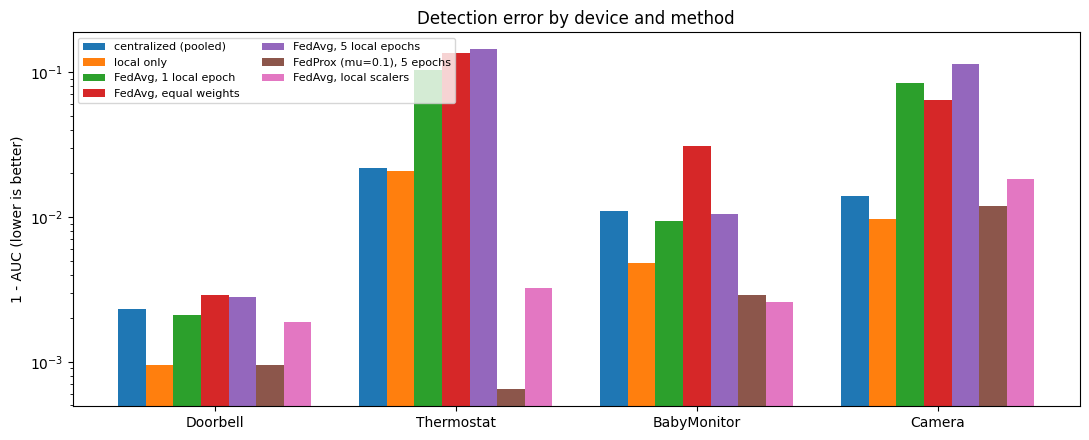

In [13]:
per_dev = pd.DataFrame(
    {SHORT[n]: {m: np.mean([results[m][s][n]["auc"] for s in SEEDS]) for m in EXPERIMENTS} for n in NAMES}
)
per_dev["mean"] = per_dev.mean(axis=1)
display(per_dev.style.format("{:.5f}"))

# plot the error (1 - AUC) on a log axis so small differences are visible. lower is better
fig, ax = plt.subplots(figsize=(11, 4.5))
width = 0.8 / len(EXPERIMENTS)
x = np.arange(len(NAMES))
for i, m in enumerate(EXPERIMENTS):
    vals = [max(1 - per_dev.loc[m, SHORT[n]], 1e-7) for n in NAMES]
    ax.bar(x + i * width, vals, width, label=m)
ax.set_xticks(x + width * (len(EXPERIMENTS) - 1) / 2)
ax.set_xticklabels([SHORT[n] for n in NAMES])
ax.set_yscale("log")
ax.set_ylabel("1 - AUC (lower is better)")
ax.set_title("Detection error by device and method")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

### How to read the results

- **Sanity check:** `FedAvg, 1 local epoch` should be close to the 0.9999 from the main notebook. If it is far off, suspect the setup, not federated learning.
- Compare methods using the `+-` column. If two methods differ by less than the seed standard deviation, treat them as tied.
- **Local only vs FedAvg** shows what federation buys. **Pooled vs FedAvg** shows what it costs.
- Check TNR too. AUC can be near 1 while 5 to 10 percent of normal traffic is still flagged.

In [14]:
def stat(method, key):
    per_seed = [np.mean([results[method][s][n][key] for n in NAMES]) for s in SEEDS]
    return f"{np.mean(per_seed):.4f} +- {np.std(per_seed, ddof=1):.4f}"   # sample std (n-1)

cols = {
    "AUC all 10": "auc",
    "AUC 8 well-posed": "auc_easy8",
    "AUC tcp+udp": "auc_hard",
    "TPR@1%FPR, 8 well-posed": "tpr_1fpr_easy8",
    "TPR@1%FPR, tcp+udp": "tpr_1fpr_hard",
    "p99 threshold: benign recall": "tnr_p99",
    "p99 threshold: attack recall (8)": "tpr_p99_easy8",
}
summary_v2 = pd.DataFrame({k: {m: stat(m, v) for m in EXPERIMENTS} for k, v in cols.items()})
display(summary_v2)
summary_v2.to_csv(os.path.join(SAVE_DIR, "ext_method_summary_v2.csv"))

print("TPR at 1% FPR on the 8 well-posed attacks, per device (mean over seeds):")
per_dev_tpr = pd.DataFrame({SHORT[n]: {m: np.mean([results[m][s][n]["tpr_1fpr_easy8"] for s in SEEDS])
                                       for m in EXPERIMENTS} for n in NAMES})
display(per_dev_tpr.style.format("{:.4f}"))

,AUC all 10,AUC 8 well-posed,AUC tcp+udp,"TPR@1%FPR, 8 well-posed","TPR@1%FPR, tcp+udp",p99 threshold: benign recall,p99 threshold: attack recall (8)
centralized (pooled),0.9877 +- 0.0027,1.0000 +- 0.0000,0.9385 +- 0.0134,0.9998 +- 0.0000,0.0837 +- 0.1442,0.9884 +- 0.0005,0.9998 +- 0.0000
local only,0.9910 +- 0.0030,1.0000 +- 0.0000,0.9551 +- 0.0151,0.9998 +- 0.0000,0.2504 +- 0.0000,0.9888 +- 0.0003,0.9998 +- 0.0000
"FedAvg, 1 local epoch",0.9506 +- 0.0301,0.9999 +- 0.0000,0.7537 +- 0.1506,0.9979 +- 0.0002,0.0835 +- 0.1442,0.9870 +- 0.0002,0.9980 +- 0.0002
"FedAvg, equal weights",0.9420 +- 0.0144,0.9999 +- 0.0000,0.7102 +- 0.0719,0.9988 +- 0.0002,0.0003 +- 0.0000,0.9875 +- 0.0002,0.9989 +- 0.0002
"FedAvg, 5 local epochs",0.9326 +- 0.0061,0.9998 +- 0.0000,0.6635 +- 0.0304,0.9972 +- 0.0004,0.0003 +- 0.0000,0.9873 +- 0.0002,0.9974 +- 0.0004
"FedProx (mu=0.1), 5 epochs",0.9959 +- 0.0016,1.0000 +- 0.0000,0.9797 +- 0.0081,0.9990 +- 0.0005,0.5830 +- 0.1442,0.9881 +- 0.0001,0.9990 +- 0.0005
"FedAvg, local scalers",0.9935 +- 0.0005,1.0000 +- 0.0000,0.9676 +- 0.0026,0.9996 +- 0.0000,0.3338 +- 0.1442,0.9928 +- 0.0006,0.9995 +- 0.0000


TPR at 1% FPR on the 8 well-posed attacks, per device (mean over seeds):


,Doorbell,Thermostat,BabyMonitor,Camera
centralized (pooled),0.9999,0.9997,0.9999,0.9996
local only,1.0000,0.9998,0.9999,0.9996
"FedAvg, 1 local epoch",0.9999,0.9996,0.9999,0.9921
"FedAvg, equal weights",0.9999,0.9997,0.9998,0.9957
"FedAvg, 5 local epochs",0.9999,0.9995,0.9998,0.9897
"FedProx (mu=0.1), 5 epochs",1.0000,1.0000,0.9999,0.9961
"FedAvg, local scalers",1.0000,1.0000,0.9999,0.9984


**Operating-point result.**

- **8 well-posed attacks:** TPR at 1% false alarms is 0.9972 to 0.9998 for every setup (lowest per-device cell: Camera, FedAvg 5 local epochs, 0.9897). At the 99th-percentile benign-train threshold, benign recall on held-out benign traffic is 0.987 to 0.993 and recall on these attacks is 0.9974 to 0.9998.
- **`gafgyt_tcp` + `gafgyt_udp`:** TPR at 1% FPR is only 0.0003 to 0.58 (FedProx 0.583, local scalers 0.334, local only 0.250, pooled 0.084, FedAvg 1 epoch 0.084, equal weights and 5 epochs 0.0003). The seed stds (0.1442 or 0.0000) are consistent with a per-device all-or-nothing outcome (not directly verified).
- **The earlier "attack recall (TPR)" column** (95th-percentile threshold, all 10 attacks) is approximately 0.8 + 0.2 x tcp/udp recall, so it mostly measures those two files.

## Experiment 2: every attack type

Per-attack AUC for the main federated model (`FedAvg, 1 local epoch`), averaged over seeds. Columns marked with `*` are the 6 attack types the first evaluation never tested.

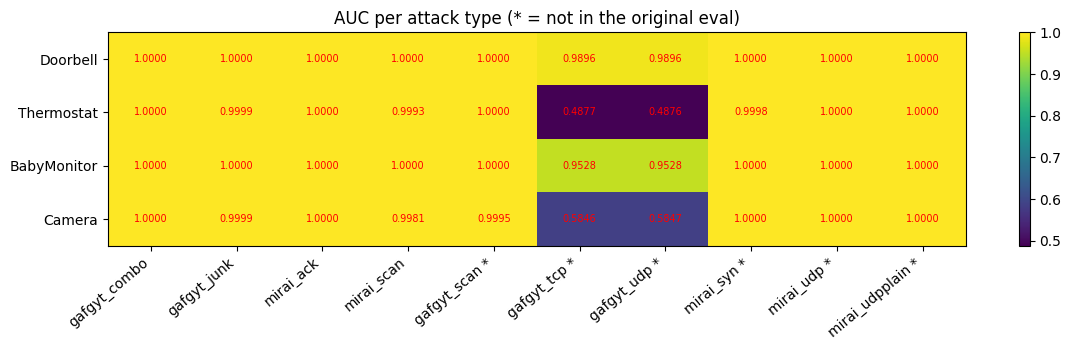

,original 4 attacks (mean AUC),6 new attacks (mean AUC),worst single attack,worst attack name
Doorbell,0.999998,0.996517,0.989551,gafgyt_udp
Thermostat,0.999811,0.829188,0.487647,gafgyt_udp
BabyMonitor,0.999991,0.984277,0.952831,gafgyt_udp
Camera,0.999488,0.861471,0.584647,gafgyt_tcp


In [16]:
MAIN = "FedAvg, 1 local epoch"
attack_types = sorted({a for n in NAMES for a in clients[n]["attacks"]})
attack_types = sorted(attack_types, key=lambda a: (a not in ORIGINAL_ATTACKS, a))
per_attack_df = pd.DataFrame(
    {a: {SHORT[n]: np.mean([results[MAIN][s][n]["per_attack"].get(a, np.nan) for s in SEEDS]) for n in NAMES}
     for a in attack_types}
)
labels = [a + ("" if a in ORIGINAL_ATTACKS else " *") for a in attack_types]

fig, ax = plt.subplots(figsize=(12, 3.6))
vals = per_attack_df.values.astype(float)
im = ax.imshow(vals, aspect="auto", cmap="viridis", vmin=np.nanmin(vals), vmax=1.0)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=40, ha="right")
ax.set_yticks(range(len(per_attack_df.index)))
ax.set_yticklabels(per_attack_df.index)
for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        if not np.isnan(vals[i, j]):
            ax.text(j, i, f"{vals[i, j]:.4f}", ha="center", va="center", fontsize=7, color="red")
ax.set_title("AUC per attack type (* = not in the original eval)")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

orig_cols = [a for a in attack_types if a in ORIGINAL_ATTACKS]
new_cols = [a for a in attack_types if a not in ORIGINAL_ATTACKS]
coverage = pd.DataFrame({
    "original 4 attacks (mean AUC)": per_attack_df[orig_cols].mean(axis=1),
    "6 new attacks (mean AUC)": per_attack_df[new_cols].mean(axis=1),
    "worst single attack": per_attack_df.min(axis=1),
    "worst attack name": per_attack_df.idxmin(axis=1),
})
coverage

### Diagnostic: are `gafgyt_tcp` and `gafgyt_udp` duplicates?

The two attacks give nearly identical AUCs on every device, and some are near 0.5.
This cell checks the raw files directly: identical rows, mean similarity, and how many
individual features separate each attack from benign traffic (with `mirai_syn` as an
easy control).

In [17]:
import numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score

DATA_DIR = "/content/data"
rng = np.random.default_rng(0)

def load(path, cap=20000):
    a = pd.read_csv(path).values.astype(np.float32)
    return a[rng.choice(len(a), cap, replace=False)] if len(a) > cap else a

def rowset(a):
    return {r.tobytes() for r in a}

def feat_aucs(benign, attack):
    # univariate AUC per feature: 0.5 = feature can't separate attack from benign
    y = np.r_[np.zeros(len(benign)), np.ones(len(attack))]
    X = np.vstack([benign, attack])
    return np.array([roc_auc_score(y, X[:, j]) for j in range(X.shape[1])])

for did in [2, 8, 1]:
    print(f"\n=== device {did} ===")
    b   = load(f"{DATA_DIR}/{did}.benign.csv")
    tcp = load(f"{DATA_DIR}/{did}.gafgyt.tcp.csv")
    udp = load(f"{DATA_DIR}/{did}.gafgyt.udp.csv")
    syn = load(f"{DATA_DIR}/{did}.mirai.syn.csv")      # control: an "easy" attack

    # 1) are tcp and udp literally the same data?
    st, su = rowset(tcp), rowset(udp)
    print(f"rows tcp/udp: {len(tcp)}/{len(udp)} | shared identical rows: {len(st & su)}")
    print(f"unique-row ratio  tcp: {len(st)/len(tcp):.3f}  udp: {len(su)/len(udp):.3f}")

    # 2) are they statistically alike?
    mt, mu, sd = tcp.mean(0), udp.mean(0), b.std(0) + 1e-8
    print(f"max |mean_tcp - mean_udp| / benign_std: {np.max(np.abs(mt - mu) / sd):.3f}")
    print(f"corr of per-feature means (tcp vs udp): {np.corrcoef(mt, mu)[0,1]:.4f}")

    # 3) how separable is each from benign, feature by feature?
    for name, atk in [("gafgyt_tcp", tcp), ("gafgyt_udp", udp), ("mirai_syn (control)", syn)]:
        a = feat_aucs(b, atk)
        sep = np.abs(a - 0.5) * 2          # 0 = useless feature, 1 = perfect
        print(f"{name:20s} features with sep>0.9: {(sep>0.9).sum():3d} | sep<0.2: {(sep<0.2).sum():3d} | best sep: {sep.max():.3f}")


=== device 2 ===
rows tcp/udp: 20000/20000 | shared identical rows: 1
unique-row ratio  tcp: 0.001  udp: 0.001
max |mean_tcp - mean_udp| / benign_std: 0.006
corr of per-feature means (tcp vs udp): 0.9977
gafgyt_tcp           features with sep>0.9:  47 | sep<0.2:  10 | best sep: 1.000
gafgyt_udp           features with sep>0.9:  47 | sep<0.2:  10 | best sep: 1.000
mirai_syn (control)  features with sep>0.9:  30 | sep<0.2:  21 | best sep: 1.000

=== device 8 ===
rows tcp/udp: 20000/20000 | shared identical rows: 1
unique-row ratio  tcp: 0.001  udp: 0.001
max |mean_tcp - mean_udp| / benign_std: 0.013
corr of per-feature means (tcp vs udp): 0.9178
gafgyt_tcp           features with sep>0.9:  51 | sep<0.2:  13 | best sep: 1.000
gafgyt_udp           features with sep>0.9:  51 | sep<0.2:  13 | best sep: 1.000
mirai_syn (control)  features with sep>0.9:  34 | sep<0.2:  23 | best sep: 1.000

=== device 1 ===
rows tcp/udp: 20000/20000 | shared identical rows: 1
unique-row ratio  tcp: 0.001  udp

**Diagnostic result.**

- **Not literal duplicates:** `gafgyt_tcp` and `gafgyt_udp` share only 1 identical row per device.
- **Near-copies:** per-feature means differ by at most 0.006 to 0.1 benign standard deviations.
- **Very repetitive:** about 20 distinct rows per 20,000 in each file, so the effective sample size is tiny and per-attack AUC for these two is noisy.
- **Easy to separate by raw features:** 47 to 51 features separate each attack from benign (separation > 0.9), more than the easy `mirai_syn` control (30 to 35).

So the AUC near 0.5 is not because the attack resembles normal traffic. Single features separate it, but the autoencoder's reconstruction error does not flag it. Why is still untested.

### Diagnostic 2: repetitiveness of every attack file, and where `tcp`/`udp` errors fall

Part A counts distinct rows in every attack file, to see whether other attacks are as
repetitive as `gafgyt_tcp`/`udp`.

Part B retrains one plain-FedAvg model and one set of local-only models (seed 0) and compares
where the reconstruction errors of `gafgyt_tcp`, `gafgyt_udp` and the easy control `mirai_syn`
fall relative to the benign test errors. If the AUC near 0.5 comes from attacks being
reconstructed about as well as (or better than) normal traffic, it will show up here.

distinct rows per attack file:


device,BabyMonitor,Camera,Doorbell,Thermostat
attack,,,,
gafgyt_combo,20000,20000,20000,20000
gafgyt_junk,20000,20000,20000,20000
gafgyt_scan,20000,20000,20000,20000
gafgyt_tcp,21,27,26,17
gafgyt_udp,22,25,22,27
mirai_ack,20000,20000,20000,20000
mirai_scan,20000,20000,20000,20000
mirai_syn,20000,20000,20000,20000
mirai_udp,20000,20000,20000,20000


distinct / total rows:


device,BabyMonitor,Camera,Doorbell,Thermostat
attack,,,,
gafgyt_combo,1.0000,1.0000,1.0000,1.0000
gafgyt_junk,1.0000,1.0000,1.0000,1.0000
gafgyt_scan,1.0000,1.0000,1.0000,1.0000
gafgyt_tcp,0.0010,0.0014,0.0013,0.0008
gafgyt_udp,0.0011,0.0012,0.0011,0.0014
mirai_ack,1.0000,1.0000,1.0000,1.0000
mirai_scan,1.0000,1.0000,1.0000,1.0000
mirai_syn,1.0000,1.0000,1.0000,1.0000
mirai_udp,1.0000,1.0000,1.0000,1.0000


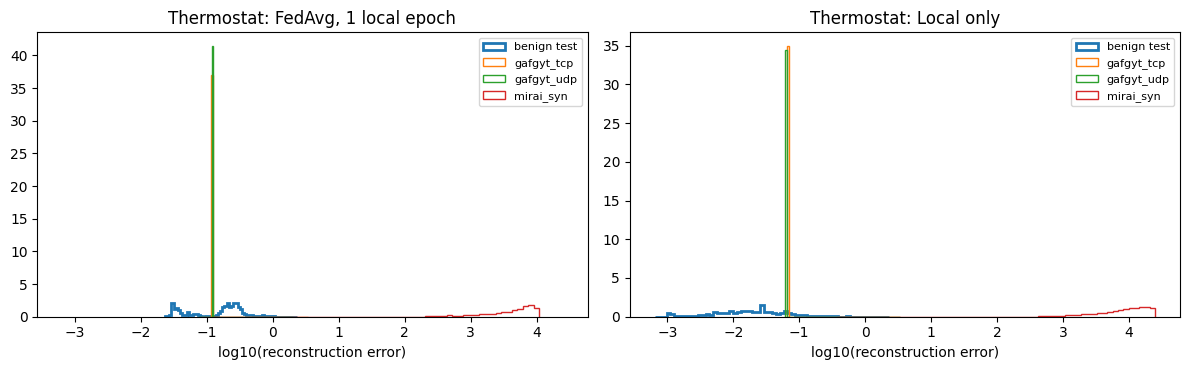

In [18]:
# ---------- Part A: how repetitive is each attack file? ----------
# note: counts are on the (up to) 20,000-row sample used in this notebook
rows = []
for n in NAMES:
    for a, X in clients[n]["attacks"].items():
        rows.append({"device": SHORT[n], "attack": a, "rows": len(X),
                     "distinct": len(np.unique(X, axis=0))})
rep = pd.DataFrame(rows)
rep["distinct_ratio"] = rep["distinct"] / rep["rows"]

print("distinct rows per attack file:")
display(rep.pivot(index="attack", columns="device", values="distinct"))
print("distinct / total rows:")
display(rep.pivot(index="attack", columns="device", values="distinct_ratio").round(4))

# ---------- Part B: where do attack errors fall vs benign? ----------
set_seed(0)
fed_model = run_federated(NAMES, SHARED_BY_CLIENT, local_epochs=1, mu=0.0,
                          weighting="size", seed=0)
local_models = run_local_only(NAMES, SHARED_BY_CLIENT, epochs=ROUNDS, seed=0)

PROBE = ["gafgyt_tcp", "gafgyt_udp", "mirai_syn"]   # mirai_syn = easy control


def error_profile(model, name, scaler, label):
    c = clients[name]
    err_b = recon_error(model, apply(scaler, c["test_benign"]))
    thr = np.percentile(recon_error(model, apply(scaler, c["train"])), 95)
    out = []
    for a in PROBE:
        if a not in c["attacks"]:
            continue
        e = recon_error(model, apply(scaler, c["attacks"][a]))
        y = np.r_[np.zeros(len(err_b)), np.ones(len(e))]
        out.append({
            "model": label, "device": SHORT[name], "attack": a,
            "benign median err": np.median(err_b),
            "attack median err": np.median(e),
            "median ratio (attack/benign)": np.median(e) / np.median(err_b),
            "% attack below benign median": 100 * (e < np.median(err_b)).mean(),
            "% attack above threshold": 100 * (e > thr).mean(),
            "AUC": roc_auc_score(y, np.r_[err_b, e]),
        })
    return out


prof = []
for n in NAMES:
    prof += error_profile(fed_model, n, SHARED, "FedAvg, 1 epoch")
    prof += error_profile(local_models[n], n, SHARED, "local only")
prof_df = pd.DataFrame(prof).set_index(["device", "attack", "model"]).sort_index()
display(prof_df.style.format({
    "benign median err": "{:.4f}", "attack median err": "{:.4f}",
    "median ratio (attack/benign)": "{:.2f}",
    "% attack below benign median": "{:.1f}", "% attack above threshold": "{:.1f}",
    "AUC": "{:.4f}"}))

# ---------- Part C: error distributions on the worst device ----------
name = [n for n in NAMES if SHORT[n] == "Thermostat"][0]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharex=True)
for ax, (title, model) in zip(axes, [("FedAvg, 1 local epoch", fed_model),
                                     ("Local only", local_models[name])]):
    eb = recon_error(model, apply(SHARED, clients[name]["test_benign"]))
    ax.hist(np.log10(eb + 1e-12), bins=60, density=True, histtype="step",
            linewidth=2, label="benign test")
    for a in PROBE:
        ea = recon_error(model, apply(SHARED, clients[name]["attacks"][a]))
        ax.hist(np.log10(ea + 1e-12), bins=60, density=True, histtype="step", label=a)
    ax.set_title(f"Thermostat: {title}")
    ax.set_xlabel("log10(reconstruction error)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("thermostat_error_profile.png", dpi=150, bbox_inches="tight")
plt.show()

**Diagnostic 2 result.**

- **Only `gafgyt_tcp` and `gafgyt_udp` are repetitive:** 17 to 27 distinct rows per 20,000. The other 8 attack files per device are fully distinct. The two make up 20% of the pooled attack rows.
- **Single fixed point:** with the shared FedAvg model and scaler, both attacks have the same median reconstruction error (0.1246) on all four devices, so they behave as one point repeated across devices (not yet verified on raw rows).
- **Weak signal:** that error is tiny next to an easy attack (`mirai_syn`: 5,000 or more).
- **Benign error floor decides the AUC:** FedAvg's median benign error is 0.204 (Thermostat) and 0.136 (Camera), above 0.125, so 99.9 to 100% of tcp/udp rows score below the median benign row (seed-0 AUC 0.31 and 0.44).
- **Local-only is better but not solved:** AUC 0.86 (Thermostat) and 0.92 (Camera), yet only 0.1% of rows exceed the 95th-percentile threshold on those devices.
- **Seed-sensitive:** seed-0 AUCs differ from the 3-seed means (Thermostat 0.31 vs 0.49, Camera 0.44 vs 0.58).

### Diagnostic 3: do the method rankings survive splitting out `tcp`/`udp`, and does benign fit explain them?

**Cell A** (no retraining) splits each method's per-attack AUC into the 8 well-posed attacks and
the 2 repetitive ones (`gafgyt_tcp`, `gafgyt_udp`), using the stored 3-seed results.

**Cell B** retrains every method once (seed 0) and records how well each model fits normal
traffic (median benign reconstruction error) next to its AUC on the hard and easy attacks.
This tests the hypothesis that methods differ mainly in how well they fit each device's normal traffic.

In [19]:
HARD = ["gafgyt_tcp", "gafgyt_udp"]

rows = []
for m in EXPERIMENTS:
    for s in SEEDS:
        pa = {n: results[m][s][n]["per_attack"] for n in NAMES}
        rows.append({
            "method": m, "seed": s,
            "all 10 (pooled AUC)": np.mean([results[m][s][n]["auc"] for n in NAMES]),
            "8 well-posed": np.mean([v for n in NAMES for a, v in pa[n].items() if a not in HARD]),
            "tcp+udp only": np.mean([pa[n][a] for n in NAMES for a in HARD]),
        })
R = pd.DataFrame(rows)

# std uses n-1 here (the README's earlier numbers use n); expect slightly larger spreads
agg = R.groupby("method", sort=False).agg(["mean", "std"]).drop(columns="seed")
fmt = pd.DataFrame({c: [f"{agg.loc[m, (c, 'mean')]:.4f} +- {agg.loc[m, (c, 'std')]:.4f}"
                        for m in agg.index] for c in ["all 10 (pooled AUC)", "8 well-posed", "tcp+udp only"]},
                   index=agg.index)
display(fmt)

print("tcp+udp AUC per device (mean over seeds):")
hard_dev = pd.DataFrame({SHORT[n]: {m: np.mean([results[m][s][n]["per_attack"][a]
                                                for s in SEEDS for a in HARD]) for m in EXPERIMENTS}
                         for n in NAMES})
display(hard_dev.style.format("{:.4f}"))

,all 10 (pooled AUC),8 well-posed,tcp+udp only
method,,,
centralized (pooled),0.9877 +- 0.0027,1.0000 +- 0.0000,0.9385 +- 0.0134
local only,0.9910 +- 0.0030,1.0000 +- 0.0000,0.9551 +- 0.0151
"FedAvg, 1 local epoch",0.9506 +- 0.0301,0.9999 +- 0.0000,0.7537 +- 0.1506
"FedAvg, equal weights",0.9420 +- 0.0144,0.9999 +- 0.0000,0.7102 +- 0.0719
"FedAvg, 5 local epochs",0.9326 +- 0.0061,0.9998 +- 0.0000,0.6635 +- 0.0304
"FedProx (mu=0.1), 5 epochs",0.9959 +- 0.0016,1.0000 +- 0.0000,0.9797 +- 0.0081
"FedAvg, local scalers",0.9935 +- 0.0005,1.0000 +- 0.0000,0.9676 +- 0.0026


tcp+udp AUC per device (mean over seeds):


,Doorbell,Thermostat,BabyMonitor,Camera
centralized (pooled),0.9884,0.8907,0.9448,0.9301
local only,0.9952,0.8972,0.9760,0.9519
"FedAvg, 1 local epoch",0.9896,0.4877,0.9528,0.5847
"FedAvg, equal weights",0.9855,0.3303,0.8448,0.6802
"FedAvg, 5 local epochs",0.9859,0.2850,0.9473,0.4359
"FedProx (mu=0.1), 5 epochs",0.9953,0.9968,0.9857,0.9410
"FedAvg, local scalers",0.9905,0.9839,0.9871,0.9089


In [20]:
from scipy.stats import spearmanr


def train_method(cfg, seed=0):
    """Returns {device: (model, scaler)} for one experiment config."""
    if cfg["kind"] == "central":
        m = run_centralized(NAMES, SHARED, epochs=ROUNDS, seed=seed)
        return {n: (m, SHARED) for n in NAMES}
    if cfg["kind"] == "local":
        ms = run_local_only(NAMES, SHARED_BY_CLIENT, epochs=ROUNDS, seed=seed)
        return {n: (ms[n], SHARED) for n in NAMES}
    sc = SHARED_BY_CLIENT if cfg["scalers"] == "shared" else LOCAL_BY_CLIENT
    m = run_federated(NAMES, sc, cfg["E"], cfg["mu"], cfg["weighting"], seed=seed)
    return {n: (m, sc[n]) for n in NAMES}


def profile(model, name, scaler):
    c = clients[name]
    eb_tr = recon_error(model, apply(scaler, c["train"]))
    eb = recon_error(model, apply(scaler, c["test_benign"]))
    easy = [a for a in c["attacks"] if a not in HARD]

    def pooled(keys):
        e = np.concatenate([recon_error(model, apply(scaler, c["attacks"][a])) for a in keys])
        y = np.r_[np.zeros(len(eb)), np.ones(len(e))]
        return roc_auc_score(y, np.r_[eb, e]), e

    auc_easy, _ = pooled(easy)
    auc_hard, e_hard = pooled(HARD)
    return {"benign_train_med": np.median(eb_tr), "benign_test_med": np.median(eb),
            "hard_attack_med": np.median(e_hard),
            "hard_below_benign_med_%": 100 * (e_hard < np.median(eb)).mean(),
            "auc_easy8": auc_easy, "auc_hard": auc_hard}


prof_rows, t0 = [], time.time()
for method, cfg in EXPERIMENTS.items():
    pair = train_method(cfg, seed=0)
    for n in NAMES:
        model, sc = pair[n]
        p = profile(model, n, sc)
        p.update(method=method, device=SHORT[n],
                 scaler="local" if cfg.get("scalers") == "local" else "shared")
        prof_rows.append(p)
    print(f"{method:32s} done ({time.time() - t0:.0f}s)")

P = pd.DataFrame(prof_rows)
display(P.set_index(["device", "method"]).sort_index().drop(columns="scaler").style.format({
    "benign_train_med": "{:.4f}", "benign_test_med": "{:.4f}", "hard_attack_med": "{:.4f}",
    "hard_below_benign_med_%": "{:.1f}", "auc_easy8": "{:.4f}", "auc_hard": "{:.4f}"}))

# Raw error values are only comparable between methods that share one scaler,
# so the correlation uses the shared-scaler methods only.
sh = P[P.scaler == "shared"]
rho, pv = spearmanr(sh["benign_test_med"], sh["auc_hard"])
print(f"\nShared-scaler methods, all devices pooled (n={len(sh)}): "
      f"Spearman(benign median error, tcp+udp AUC) = {rho:.2f} (p={pv:.3f})")
for d in sh.device.unique():
    s = sh[sh.device == d]
    r, _ = spearmanr(s["benign_test_med"], s["auc_hard"])
    print(f"  {d:12s} n={len(s)}  rho = {r:.2f}")
print("(pooled rho is driven partly by device differences; per-device n is only 6, read as direction only)")

centralized (pooled)             done (18s)
local only                       done (34s)
FedAvg, 1 local epoch            done (50s)
FedAvg, equal weights            done (66s)
FedAvg, 5 local epochs           done (141s)
FedProx (mu=0.1), 5 epochs       done (236s)
FedAvg, local scalers            done (252s)



Shared-scaler methods, all devices pooled (n=24): Spearman(benign median error, tcp+udp AUC) = -0.42 (p=0.043)
  Doorbell     n=6  rho = -0.37
  Thermostat   n=6  rho = -0.14
  BabyMonitor  n=6  rho = -0.09
  Camera       n=6  rho = -0.37
(pooled rho is driven partly by device differences; per-device n is only 6, read as direction only)


**Diagnostic 3 result.**

- **8 well-posed attacks:** all seven setups score 0.9998 to 1.0000 (pooled over the 8 attack types, mean over 4 devices, 3 seeds). Every difference in the main table comes from `gafgyt_tcp` and `gafgyt_udp`.
- **tcp+udp only (sample std, n-1):** FedProx 0.9797, local scalers 0.9676, local only 0.9551, pooled 0.9385, FedAvg 1 epoch 0.7537 (std 0.15), equal weights 0.7102, FedAvg 5 epochs 0.6635.
- **Same fixed point across devices:** for models with a shared scaler, the median tcp/udp error is identical on all four devices (0.1246 FedAvg 1 epoch, 0.0857 FedAvg 5 epochs, 0.0719 equal weights, 0.0911 pooled, 4.4455 FedProx).
- **Threshold effect (seed 0):** in the 5 of 28 device-method pairs where that error is below the device's median benign error (plain FedAvg variants on Thermostat and Camera), tcp+udp AUC is 0.31 to 0.47. In all other pairs it is above 0.83.
- **Benign fit is only a partial explanation:** Spearman(benign median error, tcp+udp AUC) = -0.42 over the 24 shared-scaler (device, method) pairs (not independent), and -0.09 to -0.37 per device (n=6). FedProx has higher benign error than FedAvg 1 epoch on 3 of 4 devices yet the best tcp+udp AUC, because its error on the fixed point is much larger.

### Diagnostic 4: is the tcp/udp point the same on every device, and how central is it?

Part A compares the distinct raw tcp/udp rows across devices (exact matches and nearest-neighbour
distance in shared-scaled space). Part B checks where the point sits relative to the fleet-average point
(the origin of the shared-scaled space) and relative to each device's own benign mean, compared with that
device's benign test rows. No model is trained here.

In [21]:
HARD = ["gafgyt_tcp", "gafgyt_udp"]
pts = {(n, a): np.unique(clients[n]["attacks"][a], axis=0) for n in NAMES for a in HARD}


def nn_dist(A, B, same=False):
    """Mean nearest-neighbour L2 distance from rows of A to rows of B, in shared-scaled space."""
    As, Bs = apply(SHARED, A), apply(SHARED, B)
    d = np.sqrt(((As[:, None, :] - Bs[None, :, :]) ** 2).sum(-1))
    if same:
        np.fill_diagonal(d, np.inf)
    return float(d.min(1).mean())


# ---- Part A: same rows across devices? ----
rowsA = []
for a in HARD:
    for i, n1 in enumerate(NAMES):
        for n2 in NAMES[i + 1:]:
            A, B = pts[(n1, a)], pts[(n2, a)]
            exact = len({r.tobytes() for r in A} & {r.tobytes() for r in B})
            rowsA.append({
                "attack": a, "pair": f"{SHORT[n1]} vs {SHORT[n2]}",
                "distinct A/B": f"{len(A)}/{len(B)}",
                "exact shared rows": exact,
                "cross-device NN dist": nn_dist(A, B),
                "within-file NN dist (A)": nn_dist(A, A, same=True),
                "mean row norm (A)": float(np.linalg.norm(apply(SHARED, A), axis=1).mean()),
            })
print("A) cross-device comparison of distinct tcp/udp rows (distances in shared-scaled space)")
display(pd.DataFrame(rowsA).set_index(["attack", "pair"]).style.format(
    {"cross-device NN dist": "{:.3f}", "within-file NN dist (A)": "{:.3f}", "mean row norm (A)": "{:.2f}"}))

# ---- Part B: where does the point sit? ----
rowsB = []
for n in NAMES:
    c = clients[n]
    Xb = apply(SHARED, c["test_benign"])
    own_mean = apply(SHARED, c["train"]).mean(0)
    b0 = (Xb ** 2).mean(1)                    # squared error if a model just output the fleet-average point
    bo = ((Xb - own_mean) ** 2).mean(1)       # squared error if a model just output this device's benign mean
    for a in HARD:
        P = apply(SHARED, pts[(n, a)])
        p0 = np.median((P ** 2).mean(1))
        po = np.median(((P - own_mean) ** 2).mean(1))
        rowsB.append({
            "device": SHORT[n], "attack": a,
            "point: err vs fleet mean": p0,
            "benign median: err vs fleet mean": np.median(b0),
            "% benign nearer fleet mean than point": 100 * (b0 < p0).mean(),
            "point: err vs own mean": po,
            "benign median: err vs own mean": np.median(bo),
            "% benign nearer own mean than point": 100 * (bo < po).mean(),
            "device benign center vs fleet mean": float((own_mean ** 2).mean()),
        })
print("\nB) position of the tcp/udp point in shared-scaled space (errors are per-feature mean squared)")
display(pd.DataFrame(rowsB).set_index(["device", "attack"]).style.format("{:.4f}"))

A) cross-device comparison of distinct tcp/udp rows (distances in shared-scaled space)



B) position of the tcp/udp point in shared-scaled space (errors are per-feature mean squared)


**Diagnostic 4 result.**

- **A small cluster shared across devices, not one point.** Each file has 17 to 27 distinct rows, and any two devices share 4 to 11 of them exactly. Cross-device nearest-neighbour distances (2.8 to 10.6 in shared-scaled space) are about the size of the spread within one file (4.8 to 10.4), against row norms of 19 to 33.
- **The distinct rows are far from normal traffic, not near the fleet average.** The typical distinct tcp/udp row is farther from the fleet-mean point than 87% to 99.6% of benign test rows (per-feature squared error 0.45 to 8.7 vs benign medians of 0.04 to 1.13). The hypothesis that the attack sits near the fleet-average point is not supported. This part uses distinct rows without frequency weighting; the heavily repeated rows that set the models' median error were not examined separately.
- **Device heterogeneity lines up with where plain FedAvg fails.** Each device's benign center is at squared distance 0.41 (Thermostat), 0.15 (Camera), 0.04 (Doorbell) and 0.015 (Baby Monitor) from the fleet mean, and plain FedAvg's tcp/udp AUC is lowest on Thermostat and Camera. With 4 devices this is suggestive only.
- **Open question:** shared-scaler models reconstruct these rows with a small error (0.07 to 0.12). Why is untested.

## Experiment 3: a device the federation never saw

Leave one device out: train FedAvg on the other 3 devices only, then test on the 4th.

Two ways the new device can be normalized when it joins:

- **Fleet scaler:** reuse the mean and std from the 3 training devices (no setup on the new device).
- **Own scaler:** the new device computes its own mean and std from its first benign traffic (a normal onboarding step).

The threshold always comes from the new device's own benign training rows.

In [ ]:
lodo_rows = []
for held in NAMES:
    others = [n for n in NAMES if n != held]
    fleet = federated_scaler(others)
    sc = {n: fleet for n in others}
    runs = {"fleet": [], "own": []}
    for seed in SEEDS:
        m = run_federated(others, sc, 1, 0.0, "size", seed=seed)
        runs["fleet"].append(evaluate(m, held, fleet))
        runs["own"].append(evaluate(m, held, LOCAL_BY_CLIENT[held]))

    def avg(kind, key):
        return float(np.mean([r[key] for r in runs[kind]]))

    lodo_rows.append({
        "held-out device": SHORT[held],
        "in federation, all 10": np.mean([results[MAIN][s][held]["auc"] for s in SEEDS]),
        "in federation, 8 well-posed": np.mean([results[MAIN][s][held]["auc_easy8"] for s in SEEDS]),
        "fleet scaler, all 10": avg("fleet", "auc"),
        "fleet scaler, 8 well-posed": avg("fleet", "auc_easy8"),
        "fleet scaler, tcp+udp": avg("fleet", "auc_hard"),
        "own scaler, all 10": avg("own", "auc"),
        "own scaler, 8 well-posed": avg("own", "auc_easy8"),
        "own scaler, tcp+udp": avg("own", "auc_hard"),
        "fleet scaler, TPR@1%FPR (8)": avg("fleet", "tpr_1fpr_easy8"),
        "own scaler, TPR@1%FPR (8)": avg("own", "tpr_1fpr_easy8"),
    })
    print("done:", SHORT[held])
lodo_df = pd.DataFrame(lodo_rows).set_index("held-out device")
lodo_df.style.format("{:.4f}")

done: Doorbell
done: Thermostat
done: BabyMonitor
done: Camera


,"in federation, all 10","in federation, 8 well-posed","fleet scaler, all 10","fleet scaler, 8 well-posed","fleet scaler, tcp+udp","own scaler, all 10","own scaler, 8 well-posed","own scaler, tcp+udp","fleet scaler, TPR@1%FPR (8)","own scaler, TPR@1%FPR (8)"
held-out device,,,,,,,,,,
Doorbell,0.9979,1.0000,0.9974,1.0000,0.9869,0.9964,1.0000,0.9822,0.9999,1.0000
Thermostat,0.8974,0.9999,0.8616,0.9998,0.3088,0.9855,1.0000,0.9275,0.9995,1.0000
BabyMonitor,0.9906,1.0000,0.9230,0.9986,0.6206,0.9820,1.0000,0.9099,0.9715,0.9998
Camera,0.9167,0.9997,0.8782,0.9995,0.3931,0.9814,0.9998,0.9079,0.9840,0.9966


**Unseen-device result (mean over 3 seeds).**

- **8 well-posed attacks:** AUC is at least 0.9986 on the new device with either scaler (fleet 0.9986 to 1.0000, own 0.9998 to 1.0000).
- **The drop in the all-10 AUC comes from tcp/udp:** fleet-scaler AUC is 0.9869 (Doorbell), 0.3088 (Thermostat), 0.6206 (Baby Monitor), 0.3931 (Camera); with its own scaler 0.9079 to 0.9822.
- **At 1% FPR on the 8 well-posed attacks,** the fleet scaler costs recall on Baby Monitor (0.9715) and Camera (0.9840); the device's own scaler gives 0.9998 and 0.9966.

## Save results

In [ ]:
summary_df.to_csv(os.path.join(SAVE_DIR, "ext_method_summary.csv"))
per_dev.to_csv(os.path.join(SAVE_DIR, "ext_per_device_auc.csv"))
per_attack_df.to_csv(os.path.join(SAVE_DIR, "ext_per_attack_auc.csv"))
lodo_df.to_csv(os.path.join(SAVE_DIR, "ext_unseen_device.csv"))
print("saved 4 csv files to", SAVE_DIR)

saved 4 csv files to /content/drive/MyDrive/nbaiot-project/processed


## Findings
Results from one full run: 3 seeds, 10 rounds, all 10 attack types per device. Mean AUC is over the 4 devices unless stated.

 Note: Diagnostic 3 shows that the method differences in the rows below come almost entirely from `gafgyt_tcp` and `gafgyt_udp`. Read them with that in mind.


| Question | Result |
|---|---|
| Non-IID: best method vs `FedAvg, 1 local epoch` (beyond seed spread?) | Yes. FedProx (5 epochs) scores 0.9959 +- 0.0013 and FedAvg with local scalers scores 0.9935 +- 0.0004, against 0.9507 +- 0.0246 for plain FedAvg. The gap of about 0.04 is much bigger than the seed spread. FedProx, local scalers and local only (0.9910 +- 0.0025) are close to each other, so I treat them as tied. |
| Non-IID: effect of 5 local epochs, and did FedProx fix it? | 5 local epochs scored 0.9326 +- 0.0050, a little lower than 1 epoch, but within its large seed spread, so not clearly worse. FedProx with the same 5 epochs reached 0.9959, so yes, it fixed it. The thermostat went from 0.857 to 0.999. |
| Non-IID: did equal weighting help the small devices? | No. Equal weights scored 0.9420 +- 0.0118, the same as plain FedAvg within noise. The thermostat did not improve (0.866 vs 0.897). Data size imbalance alone does not look like the cause. Local scaling fixing it points to differences in feature scale between devices, but this is a guess I have not tested directly. |
| Federation value: local only vs FedAvg vs pooled | Local only 0.9910, pooled 0.9877, plain FedAvg 0.9507. Once device differences are handled, federation matches or slightly beats local only (FedProx 0.9959, local scalers 0.9935), so the gain is small here. Pooled scored below local only, probably because one small autoencoder has to model four very different devices. |
| Attack coverage: mean AUC on the 6 new attacks vs the original 4 (`FedAvg, 1 local epoch`) | Original 4: 0.9995 to 1.0000 on every device. New 6: Doorbell 0.9965, Baby Monitor 0.9843, Camera 0.8615, Thermostat 0.8292. Almost all of the drop comes from two attack types, `gafgyt_tcp` and `gafgyt_udp`. The other 8 types score about 1.00 on every device. |
| Attack coverage: worst attack per device | `gafgyt_udp` for Doorbell (0.9896), Thermostat (0.4876) and Baby Monitor (0.9528). `gafgyt_tcp` for Camera (0.5846). An AUC near 0.5 is a coin flip. The tcp and udp results match to 3 or 4 decimals on every device, which suggests those two attack files look almost the same in this feature space. I have not checked this directly. |
| Unseen device: AUC drop, and does the own scaler recover it? | With the fleet scaler: Doorbell 0.9974, Thermostat 0.8616, Baby Monitor 0.9230, Camera 0.8782. With its own scaler: 0.9965, 0.9855, 0.9820, 0.9814. The own scaler recovers almost everything. Note that the "in federation" column in the table above used plain FedAvg with the shared scaler, which is the weak setup, so it is not a clean comparison. |
| Benign recall (TNR) when AUC is near 1 | TNR is 0.94 to 0.95 for every method. That is by construction, because the threshold is the 95th percentile of benign training error, so it says nothing about the model. Attack recall (TPR) varies more, from 0.85 (equal weights) to 0.966 (FedProx). |

**Main takeaway.** The first result (federated matches centralized) holds on 8 of the 10 attack types: every setup, including plain FedAvg, scores 0.9998 to 1.0000 on them. All of the difference between methods comes from `gafgyt_tcp` and `gafgyt_udp`, two near-copy attack files with about 20 distinct rows each, where plain FedAvg scores 0.66 to 0.75 and FedProx, local scalers, local only and pooled score 0.94 to 0.98. A new device computing its own scaler recovers most of the AUC in the unseen-device table, but that table pools all 10 attacks, so it is probably driven by the same two files and has not been split yet.

**Limitations**

- Only 3 seeds, so the order of the top three methods is not settled.
- The cause of the plain FedAvg failure is a hypothesis. No test isolates it.
- The tcp and udp attacks may be near duplicates. Not checked.
- Federated training is still simulated on one machine, so there is no network delay or dropped clients.
- Attack files are subsampled to 20,000 rows each.
- Only 4 of the 9 N-BaIoT devices are used.

**Not done here:** comparing FedAvg with a robust aggregator (median or trimmed mean) when one client sends poisoned updates.

## Export for the MCP server

Trains one FedAvg model with local scalers (1 local epoch, 10 rounds, seed 0), then saves the weights,
each device's scaler, benign-train thresholds, per-feature benign error baselines, a model card with
this model's own metrics, and a few demo windows.
Thresholds are benign-train percentiles only, so they need no attack labels.

In [22]:
EXPORT_DIR = os.path.join(SAVE_DIR, "mcp_export")
os.makedirs(EXPORT_DIR, exist_ok=True)

feature_names = pd.read_csv(f"{DATA_DIR}/1.benign.csv", nrows=0).columns.tolist()
assert len(feature_names) == D

export_model = run_federated(NAMES, LOCAL_BY_CLIENT, local_epochs=1, mu=0.0,
                             weighting="size", rounds=ROUNDS, seed=0)
torch.save({k: v.cpu() for k, v in export_model.state_dict().items()}, f"{EXPORT_DIR}/model.pt")

config = {
    "method": "FedAvg, local scalers, 1 local epoch, 10 rounds, seed 0",
    "architecture": {"input_dim": D, "hidden": 64, "latent": 16},
    "feature_names": feature_names,
    "devices": {},
}
card = {}
rng = np.random.default_rng(0)
demo = {}

for n in NAMES:
    c = clients[n]
    sc = LOCAL_BY_CLIENT[n]
    Xtr = apply(sc, c["train"])
    err_tr = recon_error(export_model, Xtr)
    thr95, thr99 = np.percentile(err_tr, [95, 99])
    with torch.no_grad():
        xb = to_tensor(Xtr)
        feat_err = ((export_model(xb) - xb) ** 2).mean(0).cpu().numpy()   # per-feature benign baseline

    ev = evaluate(export_model, n, sc)
    per_attack = {a: float((recon_error(export_model, apply(sc, X)) > thr99).mean())
                  for a, X in c["attacks"].items()}

    config["devices"][SHORT[n]] = {
        "full_name": n,
        "scaler_mean": sc[0].tolist(), "scaler_std": sc[1].tolist(),
        "threshold_p95": float(thr95), "threshold_p99": float(thr99),
        "benign_train_median_error": float(np.median(err_tr)),
        "benign_feature_error": feat_err.tolist(),
    }
    card[SHORT[n]] = {
        "benign_train_rows": int(len(c["train"])),
        "benign_test_recall_at_p99": ev["tnr_p99"],
        "attack_recall_at_p99_all10": ev["tpr_p99"],
        "attack_recall_at_p99_8_well_posed": ev["tpr_p99_easy8"],
        "auc_all10": ev["auc"], "auc_8_well_posed": ev["auc_easy8"], "auc_tcp_udp": ev["auc_hard"],
        "per_attack_recall_at_p99": per_attack,
    }

    # demo windows: a typical benign test row (closest to median error), plus attack rows
    eb = recon_error(export_model, apply(sc, c["test_benign"]))
    typical = int(np.argmin(np.abs(eb - np.median(eb))))
    pick = lambda arr: arr[int(rng.integers(len(arr)))].tolist()
    demo[SHORT[n]] = {
        "benign_typical": c["test_benign"][typical].tolist(),
        "mirai_syn": pick(c["attacks"]["mirai_syn"]),
        "gafgyt_combo": pick(c["attacks"]["gafgyt_combo"]),
        "gafgyt_tcp": c["attacks"]["gafgyt_tcp"][0].tolist(),
    }

card["_note"] = ("Metrics are for this single exported model (seed 0), not the 3-seed means in the README. "
                 "Thresholds are the 99th percentile of benign TRAIN error. Benign recall is measured on "
                 "the held-out last 30% of each benign capture. gafgyt_tcp/udp are weakly detected on some devices.")
for name, obj in [("config.json", config), ("model_card.json", card), ("demo_windows.json", demo)]:
    with open(f"{EXPORT_DIR}/{name}", "w") as f:
        json.dump(obj, f)

# sanity: reload from disk into a fresh model and check scores match
reloaded = Autoencoder(D).to(DEVICE)
reloaded.load_state_dict(torch.load(f"{EXPORT_DIR}/model.pt"))
probe = apply(LOCAL_BY_CLIENT[NAMES[0]], clients[NAMES[0]]["test_benign"][:1000])
assert np.allclose(recon_error(export_model, probe), recon_error(reloaded, probe), atol=1e-6)
print("saved to", EXPORT_DIR, "| reload check passed")

summary = pd.DataFrame({d: {
    "threshold_p99": config["devices"][d]["threshold_p99"],
    "benign recall@p99": card[d]["benign_test_recall_at_p99"],
    "attack recall@p99, all 10": card[d]["attack_recall_at_p99_all10"],
    "attack recall@p99, 8 well-posed": card[d]["attack_recall_at_p99_8_well_posed"],
    "recall@p99 gafgyt_tcp": card[d]["per_attack_recall_at_p99"]["gafgyt_tcp"],
    "recall@p99 gafgyt_udp": card[d]["per_attack_recall_at_p99"]["gafgyt_udp"],
} for d in config["devices"]})
display(summary.style.format("{:.4f}"))

saved to /content/drive/MyDrive/nbaiot-project/processed/mcp_export | reload check passed


,Doorbell,Thermostat,BabyMonitor,Camera
threshold_p99,1.8405,1.2324,0.8264,1.5973
benign recall@p99,0.9862,0.9962,0.9931,0.9942
"attack recall@p99, all 10",1.0000,0.8002,0.8000,0.7989
"attack recall@p99, 8 well-posed",1.0000,1.0000,0.9999,0.9985
recall@p99 gafgyt_tcp,1.0000,0.0008,0.0003,0.0010
recall@p99 gafgyt_udp,1.0000,0.0012,0.0003,0.0004


In [23]:
grid = list(range(0, 100)) + [99.5, 99.9, 99.99, 100]

with open(f"{EXPORT_DIR}/config.json") as f:
    cfg = json.load(f)

rank_rows = []
for n in NAMES:
    d, sc = SHORT[n], LOCAL_BY_CLIENT[n]
    err_tr = recon_error(export_model, apply(sc, clients[n]["train"]))
    cfg["devices"][d]["benign_error_grid"] = {
        "pct": grid, "err": [float(np.percentile(err_tr, p)) for p in grid]}
    row = {"device": d}
    for a in ["gafgyt_tcp", "gafgyt_udp", "mirai_syn"]:
        e = recon_error(export_model, apply(sc, clients[n]["attacks"][a]))
        # share of benign TRAIN windows whose error is below this attack's median error
        row[f"{a}: median score percentile"] = 100 * float(np.mean(err_tr < np.median(e)))
    rank_rows.append(row)

with open(f"{EXPORT_DIR}/config.json", "w") as f:
    json.dump(cfg, f)
display(pd.DataFrame(rank_rows).set_index("device").style.format("{:.2f}"))

,gafgyt_tcp: median score percentile,gafgyt_udp: median score percentile,mirai_syn: median score percentile
device,,,
Doorbell,99.31,99.31,100.00
Thermostat,97.39,97.39,100.00
BabyMonitor,97.23,97.23,100.00
Camera,90.43,90.43,100.00


### Write `model.npz` and verify NumPy inference

The MCP server runs the model in plain NumPy, so it does not need PyTorch. This cell converts the exported
weights and checks that the NumPy forward pass matches PyTorch on every demo window of every device.

In [24]:
import os, json, numpy as np, torch, torch.nn as nn

try:
    from google.colab import drive
    if not os.path.exists("/content/drive/MyDrive"):
        drive.mount("/content/drive")
except ImportError:
    pass

EXPORT_DIR = "/content/drive/MyDrive/nbaiot-project/processed/mcp_export"
KEYMAP = {"encoder.0.weight": "W1", "encoder.0.bias": "b1", "encoder.2.weight": "W2", "encoder.2.bias": "b2",
          "decoder.0.weight": "W3", "decoder.0.bias": "b3", "decoder.2.weight": "W4", "decoder.2.bias": "b4"}

sd = torch.load(f"{EXPORT_DIR}/model.pt", map_location="cpu")
arrays = {KEYMAP[k]: v.numpy().astype(np.float32) for k, v in sd.items()}
np.savez(f"{EXPORT_DIR}/model.npz", **arrays)
print("wrote", f"{EXPORT_DIR}/model.npz", {k: v.shape for k, v in arrays.items()})

cfg = json.load(open(f"{EXPORT_DIR}/config.json"))
demo = json.load(open(f"{EXPORT_DIR}/demo_windows.json"))
D = len(cfg["feature_names"])


class AE(nn.Module):
    def __init__(self, d, latent=16):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(d, 64), nn.ReLU(), nn.Linear(64, latent), nn.ReLU())
        self.decoder = nn.Sequential(nn.Linear(latent, 64), nn.ReLU(), nn.Linear(64, d))
    def forward(self, x):
        return self.decoder(self.encoder(x))


model = AE(D)
model.load_state_dict(sd)
model.eval()


def np_forward(xs):
    a = arrays
    h = np.maximum(xs @ a["W1"].T + a["b1"], 0)
    z = np.maximum(h @ a["W2"].T + a["b2"], 0)
    h2 = np.maximum(z @ a["W3"].T + a["b3"], 0)
    return h2 @ a["W4"].T + a["b4"]


worst = 0.0
for dev, c in cfg["devices"].items():
    mean, std = np.asarray(c["scaler_mean"]), np.asarray(c["scaler_std"])
    for name, row in demo[dev].items():
        xs = ((np.asarray(row, dtype=np.float64) - mean) / std).astype(np.float32)
        with torch.no_grad():
            t = float(((model(torch.from_numpy(xs)) - torch.from_numpy(xs)) ** 2).mean())
        n = float(((xs - np_forward(xs)).astype(np.float64) ** 2).mean())
        rel = abs(t - n) / max(abs(t), 1e-12)
        worst = max(worst, rel)
        print(f"{dev:12s} {name:14s} torch={t:.6g} numpy={n:.6g} rel_diff={rel:.1e}")

assert worst < 1e-3, f"MISMATCH: worst relative difference {worst:.2e}"
print(f"\nOK: NumPy matches PyTorch (worst relative difference {worst:.1e})")

try:
    from google.colab import files
    files.download(f"{EXPORT_DIR}/model.npz")
except ImportError:
    pass

wrote /content/drive/MyDrive/nbaiot-project/processed/mcp_export/model.npz {'W1': (64, 115), 'b1': (64,), 'W2': (16, 64), 'b2': (16,), 'W3': (64, 16), 'b3': (64,), 'W4': (115, 64), 'b4': (115,)}
Doorbell     benign_typical torch=0.0960116 numpy=0.0960116 rel_diff=1.5e-07
Doorbell     mirai_syn      torch=4.08932e+06 numpy=4.08932e+06 rel_diff=6.6e-09
Doorbell     gafgyt_combo   torch=1.27344e+06 numpy=1.27344e+06 rel_diff=7.2e-08
Doorbell     gafgyt_tcp     torch=2.58108 numpy=2.58108 rel_diff=3.6e-07
Thermostat   benign_typical torch=0.199555 numpy=0.199555 rel_diff=8.9e-08
Thermostat   mirai_syn      torch=1.87512e+06 numpy=1.87512e+06 rel_diff=6.5e-08
Thermostat   gafgyt_combo   torch=603528 numpy=603528 rel_diff=9.5e-08
Thermostat   gafgyt_tcp     torch=0.64925 numpy=0.64925 rel_diff=8.7e-08
BabyMonitor  benign_typical torch=0.00724262 numpy=0.00724262 rel_diff=3.4e-07
BabyMonitor  mirai_syn      torch=11563.7 numpy=11563.7 rel_diff=9.7e-08
BabyMonitor  gafgyt_combo   torch=829.826

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>